In [86]:
import pandas as pd 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [74]:
hall_mark_file_path = "/home/licongcong/Desktop/TCGA/tcga-gbm/Hallmark/hallmark_pathways.csv"
reactome_file_path = "/home/licongcong/Desktop/TCGA/tcga-gbm/Reactome/reactome_pathways.csv"
clincal_file_path = "/home/licongcong/Desktop/TCGA/tcga-gbm/TCGA_GBM_clinicalMatrix.csv"
genomic_file_path = "/home/licongcong/Desktop/TCGA/tcga-gbm/genomic_data_clean.csv"

In [37]:
# analysis for hallmark pathways
hallmark_df = pd.read_csv(hall_mark_file_path, header=None)
hallmark_df.rename(columns={0: 'pathway', 1:'geneset'}, inplace=True)

print("Hallmark Pathways DataFrame:")
print(hallmark_df.shape)
print(hallmark_df.head())

Hallmark Pathways DataFrame:
(50, 2)
                        pathway  \
0         HALLMARK_ADIPOGENESIS   
1  HALLMARK_ALLOGRAFT_REJECTION   
2    HALLMARK_ANDROGEN_RESPONSE   
3         HALLMARK_ANGIOGENESIS   
4      HALLMARK_APICAL_JUNCTION   

                                             geneset  
0  ABCA1,ABCB8,ACAA2,ACADL,ACADM,ACADS,ACLY,ACO2,...  
1  AARS1,ABCE1,ABI1,ACHE,ACVR2A,AKT1,APBB1,B2M,BC...  
2  ABCC4,ABHD2,ACSL3,ACTN1,ADAMTS1,ADRM1,AKAP12,A...  
3  APOH,APP,CCND2,COL3A1,COL5A2,CXCL6,FGFR1,FSTL1...  
4  ACTA1,ACTB,ACTC1,ACTG1,ACTG2,ACTN1,ACTN2,ACTN3...  


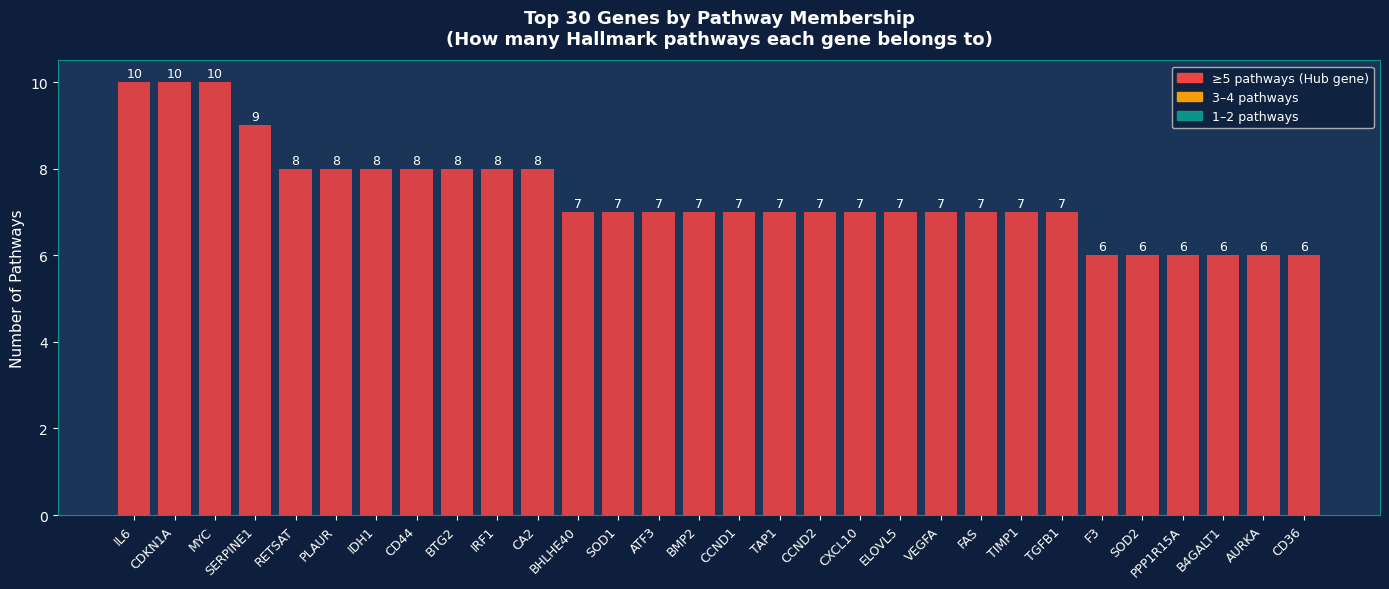

Saved: fig3_gene_pathway_membership.png


In [88]:
def plot_pathway_membership_per_gene(df_matrix, top_n=30):
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0D1F3C')
    ax.set_facecolor('#1A3558')

    # How many pathways each gene belongs to
    gene_counts = df_matrix.sum(axis=1).sort_values(ascending=False)
    top_genes   = gene_counts.head(top_n)

    colors = ['#EF4444' if c >= 5 else
              '#F59E0B' if c >= 3 else
              '#0D9488'
              for c in top_genes.values]

    bars = ax.bar(range(len(top_genes)),
                  top_genes.values,
                  color=colors, alpha=0.9)

    # Value labels
    for bar, val in zip(bars, top_genes.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                str(int(val)),
                ha='center', va='bottom',
                fontsize=9, color='white')

    ax.set_xticks(range(len(top_genes)))
    ax.set_xticklabels(top_genes.index,
                       rotation=45, ha='right',
                       fontsize=9, color='white')
    ax.set_ylabel("Number of Pathways",
                  color='white', fontsize=11)
    ax.set_title(
        f"Top {top_n} Genes by Pathway Membership\n"
        f"(How many Hallmark pathways each gene belongs to)",
        fontsize=13, fontweight='bold',
        color='white', pad=12
    )
    ax.tick_params(colors='white')

    # Legend
    legend_elements = [
        mpatches.Patch(color='#EF4444', label='≥5 pathways (Hub gene)'),
        mpatches.Patch(color='#F59E0B', label='3–4 pathways'),
        mpatches.Patch(color='#0D9488', label='1–2 pathways'),
    ]
    ax.legend(handles=legend_elements,
              facecolor='#0D1F3C',
              labelcolor='white', fontsize=9)

    for spine in ax.spines.values():
        spine.set_edgecolor('#0D9488')

    plt.tight_layout()
    plt.savefig('fig3_gene_pathway_membership.png',
                dpi=150, bbox_inches='tight',
                facecolor='#0D1F3C')
    plt.show()
    print("Saved: fig3_gene_pathway_membership.png")

plot_pathway_membership_per_gene(df_matrix, top_n=30)

In [103]:
# build the pathway-gene mapping dictionary
pathway_gene_dict = {}
for _, row in hallmark_df.iterrows():
    pathway = row['pathway']
    genes = str(row["geneset"]).split(",")
    pathway_gene_dict[pathway] = genes
    print(f"Pathway: {pathway}, Number of genes: {len(genes)}")

all_genes = set()
for genes in pathway_gene_dict.values():
    all_genes.update(genes)
print(f"Total unique genes in hallmark pathways: {len(all_genes)}")

df_matrix = pd.DataFrame(0, index=sorted(all_genes), columns=pathway_gene_dict.keys())
df_matrix.rename(columns={df_matrix.columns[-1]: 'gene_name'}, inplace=True)
print()

# Step 5: Fill matrix
for pathway, genes in pathway_gene_dict.items():
    for gene in genes:
        if gene in df_matrix.index:
            df_matrix.loc[gene, pathway] = 1

df_matrix = df_matrix.reset_index()
df_matrix.rename(columns={'index': 'gene_name'}, inplace=True)

# Step 6: Save to CSV
df_matrix.to_csv("/home/licongcong/Desktop/TCGA/tcga-gbm/Hallmark/gene_pathway_matrix.csv", index=False)

Pathway: HALLMARK_ADIPOGENESIS, Number of genes: 200
Pathway: HALLMARK_ALLOGRAFT_REJECTION, Number of genes: 200
Pathway: HALLMARK_ANDROGEN_RESPONSE, Number of genes: 101
Pathway: HALLMARK_ANGIOGENESIS, Number of genes: 36
Pathway: HALLMARK_APICAL_JUNCTION, Number of genes: 200
Pathway: HALLMARK_APICAL_SURFACE, Number of genes: 44
Pathway: HALLMARK_APOPTOSIS, Number of genes: 161
Pathway: HALLMARK_BILE_ACID_METABOLISM, Number of genes: 112
Pathway: HALLMARK_CHOLESTEROL_HOMEOSTASIS, Number of genes: 74
Pathway: HALLMARK_COAGULATION, Number of genes: 138
Pathway: HALLMARK_COMPLEMENT, Number of genes: 200
Pathway: HALLMARK_DNA_REPAIR, Number of genes: 150
Pathway: HALLMARK_E2F_TARGETS, Number of genes: 200
Pathway: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION, Number of genes: 200
Pathway: HALLMARK_ESTROGEN_RESPONSE_EARLY, Number of genes: 200
Pathway: HALLMARK_ESTROGEN_RESPONSE_LATE, Number of genes: 200
Pathway: HALLMARK_FATTY_ACID_METABOLISM, Number of genes: 158
Pathway: HALLMARK_G2M_CH

In [158]:
# analysis for genomic data of hallmark pathways
genomic_df = pd.read_csv(genomic_file_path, header=None)
genomic_df.rename(columns={0: 'gene_names', 1:'patient_id', 2:'expression'}, inplace=True)

# print("Genomic DataFrame:")
print(genomic_df.shape)
print()
print(genomic_df.head())

hallmark_df = pd.read_csv("/home/licongcong/Desktop/TCGA/tcga-gbm/Hallmark/gene_pathway_matrix.csv")
hallmark_gene_df = hallmark_df.iloc[:, [0]]
print(hallmark_gene_df.head())
print(f"Hallmark Pathway Matrix DataFrame:{hallmark_gene_df.head()}")

(17412111, 3)

  gene_names    patient_id  expression
0  5_8S_rRNA  TCGA-02-0003           0
1  5_8S_rRNA  TCGA-02-0016           0
2  5_8S_rRNA  TCGA-02-0026           0
3  5_8S_rRNA  TCGA-02-0033           0
4  5_8S_rRNA  TCGA-02-0038           0
  gene_name
0       A2M
1      AAAS
2     AADAT
3     AARS1
4      ABAT
Hallmark Pathway Matrix DataFrame:  gene_name
0       A2M
1      AAAS
2     AADAT
3     AARS1
4      ABAT


In [154]:
print(set(genomic_df["gene_names"]) & set(hallmark_gene_df["gene_name"]))

{'NOL8', 'CDH8', 'MPI', 'THBD', 'TNFSF15', 'IFRD1', 'FGF17', 'IL15', 'MAP3K7', 'MTOR', 'AUTS2', 'METAP1', 'PDE6B', 'RPA1', 'DKC1', 'PDHA1', 'HNRNPA3', 'C1QA', 'HSPA1L', 'NCBP1', 'GPAT4', 'KDELR3', 'SFRP4', 'PCYT2', 'SKIL', 'TEX15', 'YPEL5', 'CLN8', 'CIITA', 'LHX2', 'PDLIM4', 'CDK5RAP2', 'ATP6V1F', 'TGIF2', 'ATP6V1B1', 'NCOA3', 'PIK3CA', 'RSL1D1', 'SMC4', 'APOM', 'MMP7', 'CTLA4', 'ATP6V0C', 'MLLT10', 'VPS28', 'GAA', 'HUWE1', 'HMGB2', 'RANBP10', 'IFI27', 'TNFRSF9', 'IFT88', 'UBE2L6', 'ACSL3', 'LFNG', 'CES1', 'MMP2', 'SSH2', 'TMEM50A', 'UBE2J1', 'USP1', 'PCDHB1', 'GAB2', 'MYH7', 'POLR1C', 'RBM5', 'ACSL1', 'SULT2B1', 'SNCG', 'NT5C', 'IFIT3', 'SIK1', 'XPNPEP1', 'CAMK4', 'CSF3R', 'TNFRSF4', 'SPEG', 'DYRK3', 'CLP1', 'UCK1', 'CAV2', 'NME1', 'ATP1A3', 'NFASC', 'PSMA7', 'AVPR1A', 'CDKN1C', 'GALK2', 'CLIC3', 'NDUFB6', 'LAMB3', 'YIF1A', 'HMGB3', 'AKAP13', 'SLC7A11', 'ADH4', 'ARAP3', 'POLE', 'PURA', 'NOCT', 'NEDD4L', 'VAPA', 'HEYL', 'PEX6', 'SLC6A6', 'CLEC5A', 'PTRH2', 'RFC2', 'ATOX1', 'ADAMTS1', '

In [155]:
# Filter
df_filter = genomic_df[
    genomic_df["gene_names"].isin(hallmark_gene_df["gene_name"])
]

print(df_filter.head())
print("Filtered shape:", df_filter.shape)

     gene_names    patient_id  expression
1758        A2M  TCGA-02-0003         258
1759        A2M  TCGA-02-0016         189
1760        A2M  TCGA-02-0026          91
1761        A2M  TCGA-02-0033        2534
1762        A2M  TCGA-02-0038         266
Filtered shape: (1280703, 3)


In [156]:
df_pivot = df_filter.pivot_table(
    index="patient_id",
    columns="gene_names",
    values="expression",
    aggfunc="sum",
    fill_value=0
)
df_pivot.to_csv("/home/licongcong/Desktop/TCGA/tcga-gbm/genomic_clean_pivot.csv")

In [165]:
df_pivot = pd.read_csv("/home/licongcong/Desktop/TCGA/tcga-gbm/genomic_clean_pivot.csv")
print(df_pivot.head(), df_pivot.columns)

     patient_id   A2M  AAAS  AADAT  AARS1  ABAT  ABCA1  ABCA2  ABCA3  ABCA4  \
0  TCGA-02-0003   258    11      5     24    50     23     15     18      0   
1  TCGA-02-0016   189    12      2     26    40     35     12     25      0   
2  TCGA-02-0026    91    15      3     15    27     91     31     21      0   
3  TCGA-02-0033  2534    10      1     29     5    109     12     13      0   
4  TCGA-02-0038   266    12      1     23    37     45     22     26      0   

   ...  ZNF292  ZNF365  ZNF639  ZNF707  ZNFX1  ZNRF4  ZPBP  ZW10  ZWINT  ZYX  
0  ...       7       2       7       1     11      0     0    10     10   21  
1  ...       8       2       6       2     22      0     0     9      4   36  
2  ...      14       2       5       2     11      0     0    13     37   16  
3  ...       5       1       4       2     28      0     0     9     13   54  
4  ...       4       1       4       1     24      0     0     6      7   36  

[5 rows x 4372 columns] Index(['patient_id', 'A2M'

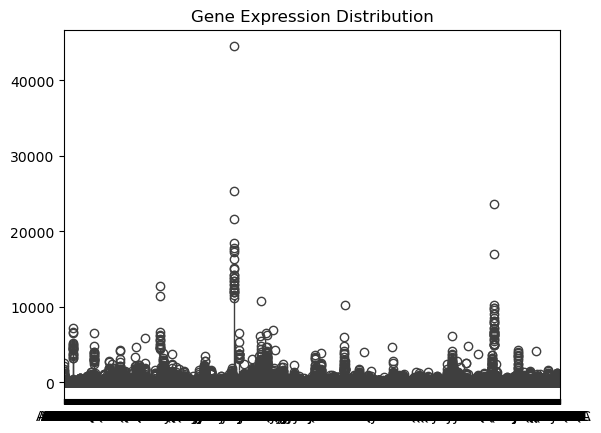

In [173]:
sns.boxplot(data=df_pivot.drop(columns=["patient_id"]))
plt.title("Gene Expression Distribution")
plt.show()